In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import json
from tqdm import tqdm

check_json_dir = "/content/aug_sampling_data/annotations"

bad_files = []

print("BBox 개수 유효성 검사 시작...")
json_files = [f for f in os.listdir(check_json_dir) if f.endswith('.json')]

for j_file in json_files:
    file_path = os.path.join(check_json_dir, j_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
            for ann in data.get('annotations', []):
                bbox = ann.get('bbox', [])

                if not isinstance(bbox, list) or len(bbox) != 4:
                    bad_files.append({
                        "file_name": j_file,
                        "wrong_bbox": bbox,
                        "length": len(bbox) if isinstance(bbox, list) else "Not a list"
                    })
        except Exception as e:
            print(f"파일 읽기 오류 ({j_file}): {e}")

print(f"총 {len(bad_files)}개의 불량 객체")
print("-" * 50)

if bad_files:
    for i, item in enumerate(bad_files[:10]):
        print(f"[{i+1}] 파일명: {item['file_name']}")
        print(f"    ㄴ 실제 bbox 값: {item['wrong_bbox']} (길이: {item['length']})")

    if len(bad_files) > 10:
        print(f"... 외 {len(bad_files) - 10}개의 오류가 더 있습니다.")
else:
    print("모든 파일의 BBox가 유효함")

BBox 개수 유효성 검사 시작...
총 0개의 불량 객체
--------------------------------------------------
모든 파일의 BBox가 유효함


# YOLO

In [ ]:
!pip install -U ultralytics wandb

from ultralytics import YOLO
import wandb
from wandb.integration.ultralytics import add_wandb_callback

In [ ]:
import os
import json
import random
import yaml
import shutil
from glob import glob
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split

PILL_DATASET_ROOT = "/content/aug_sampling_data"
SRC_IMG_DIR = os.path.join(PILL_DATASET_ROOT, "images")
SRC_JSON_DIR = os.path.join(PILL_DATASET_ROOT, "annotations")

YOLO_ROOT = "/content/pill_yolo"

PILL_NAMES = [
    "보령부스파정 5mg", "뮤테란캡슐 100mg", "일양하이트린정 2mg", "기넥신에프정(은행엽엑스)(수출용)",
    "무코스타정(레바미피드)(비매품)", "알드린정", "뉴로메드정(옥시라세탐)", "에어탈정(아세클로페낙)",
    "리렉스펜정 300mg/PTP", "아빌리파이정 10mg", "다보타민큐정 10mg/병", "써스펜8시간이알서방정 650mg",
    "에빅사정(메만틴염산염)(비매품)", "리피토정 20mg", "크레스토정 20mg", "가바토파정 100mg",
    "동아가바펜틴정 800mg", "오마코연질캡슐(오메가-3-산에틸에스테르90)", "리리카캡슐 150mg", "종근당글리아티린연질캡슐(콜린알포세레이트)",
    "콜리네이트연질캡슐 400mg", "트루비타정 60mg/병", "스토가정 10mg", "노바스크정 5mg",
    "마도파정", "플라빅스정 75mg", "엑스포지정 5/160mg", "아토르바정 10mg",
    "라비에트정 20mg", "리피로우정 20mg", "자누비아정 50mg", "맥시부펜이알정 300mg",
    "놀텍정 10mg", "자누메트정 50/850mg", "큐시드정 31.5mg/PTP", "아모잘탄정 5/100mg",
    "트윈스타정 40/5mg", "카나브정 60mg", "울트라셋이알서방정", "졸로푸트정 100mg",
    "트라젠타정(리나글립틴)", "비모보정 500/20mg", "레일라정", "리바로정 4mg",
    "트라젠타듀오정 2.5/850mg", "아질렉트정(라사길린메실산염)", "자누메트엑스알서방정 100/1000mg", "글리아타민연질캡슐",
    "신바로정", "에스원엠프정 20mg", "글리틴정(콜린알포세레이트)", "제미메트서방정 50/1000mg",
    "아토젯정 10/40mg", "로수젯정10/5밀리그램", "로수바미브정 10/20mg", "카발린캡슐 25mg"
]

In [ ]:
import cv2
import numpy as np

def apply_clahe(img_path):         # 이미지를 읽고 CLAHE 적용 후 반환
    img = cv2.imread(img_path)
    if img is None: return None

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE 적용 (대비 강화)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # 다시 BGR로 복원
    lab = cv2.merge((l, a, b))
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return result

In [ ]:
def extract_combo_key(stem):
    return stem.split("_")[0]

def process_items(items, split, clahe_p=0.5):
    dst_img_dir = os.path.join(YOLO_ROOT, 'images', split)
    dst_lbl_dir = os.path.join(YOLO_ROOT, 'labels', split)

    saved_count = 0
    skipped_count = 0
    bad_bbox_count = 0
    clahe_applied_count = 0 # 얼마나 적용됐는지 확인용

    for item in tqdm(items, desc=f"Processing {split}"):
        try:
            with open(item['json'], 'r', encoding='utf-8') as f:
                data = json.load(f)

            img_info = data['images'][0]
            width, height = img_info['width'], img_info['height']

            lines = []
            for ann in data.get('annotations', []):
                bbox = ann.get('bbox', [])

                if not isinstance(bbox, list) or len(bbox) != 4:
                    continue

                cls_id = ann['category_id']
                x, y, w, h = bbox

                xc = (x + w / 2.0) / width
                yc = (y + h / 2.0) / height
                wn = w / width
                hn = h / height

                if not all(0 <= val <= 1 for val in [xc, yc, wn, hn]):
                    bad_bbox_count += 1
                    continue

                lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

            if lines:
                dst_img_path = os.path.join(dst_img_dir, os.path.basename(item['img']))

                # --- CLAHE 적용 로직 시작 ---
                # 설정한 확률(clahe_p)에 따라 CLAHE 적용 결정
                if np.random.random() < clahe_p:
                    processed_img = apply_clahe(item['img'])
                    if processed_img is not None:
                        cv2.imwrite(dst_img_path, processed_img) # 처리된 이미지 저장
                        clahe_applied_count += 1
                    else:
                        shutil.copy2(item['img'], dst_img_path) # 실패 시 원본 복사
                else:
                    shutil.copy2(item['img'], dst_img_path) # 원본 복사
                # --- CLAHE 적용 로직 끝 ---

                label_path = os.path.join(dst_lbl_dir, f"{item['stem']}.txt")
                with open(label_path, 'w', encoding='utf-8') as f:
                    f.write("\n".join(lines))
                saved_count += 1
            else:
                skipped_count += 1

        except Exception as e:
            print(f"Error processing {item['stem']}: {e}")
            skipped_count += 1

    print(f"\n{split} 완료: 저장 {saved_count}개 (CLAHE 적용: {clahe_applied_count}개), 제외 {skipped_count}개")

def build_yolo_dataset():
    if os.path.exists(YOLO_ROOT): shutil.rmtree(YOLO_ROOT)
    for split in ['train', 'val']:
        os.makedirs(os.path.join(YOLO_ROOT, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(YOLO_ROOT, 'labels', split), exist_ok=True)

    img_paths = sorted(glob(os.path.join(SRC_IMG_DIR, "*.png")))
    combo_groups = defaultdict(list)

    for ip in img_paths:
        stem = Path(ip).stem
        json_path = os.path.join(SRC_JSON_DIR, stem + ".json")
        if os.path.exists(json_path):
            combo_key = extract_combo_key(stem)
            combo_groups[combo_key].append({'img': ip, 'json': json_path, 'stem': stem})

    combo_keys = sorted(list(combo_groups.keys()))
    train_keys, val_keys = train_test_split(combo_keys, test_size=0.2, random_state=42)

    train_items = [item for k in train_keys for item in combo_groups[k]]
    val_items = [item for k in val_keys for item in combo_groups[k]]

    process_items(train_items, 'train', clahe_p=0.5)      # CLAHE는 train에만 적용. val은 원본 유지
    process_items(val_items, 'val', clahe_p=0.0)

    yaml_content = {
        'train': os.path.join(YOLO_ROOT, 'images/train'),
        'val': os.path.join(YOLO_ROOT, 'images/val'),
        'nc': len(PILL_NAMES),
        'names': PILL_NAMES
    }
    with open(os.path.join(YOLO_ROOT, 'data.yaml'), 'w', encoding='utf-8') as f:
        yaml.dump(yaml_content, f, allow_unicode=True, sort_keys=False)

    print(f"\nYOLO 데이터셋 빌드 완료: {YOLO_ROOT}")
    print(f"Train 이미지: {len(train_items)} | Val 이미지: {len(val_items)}")

In [ ]:
build_yolo_dataset()

Processing train: 100%|██████████| 6268/6268 [08:28<00:00, 12.32it/s]



train 완료: 저장 6268개 (CLAHE 적용: 3165개), 제외 0개


Processing val: 100%|██████████| 1560/1560 [00:36<00:00, 42.92it/s]


val 완료: 저장 1560개 (CLAHE 적용: 0개), 제외 0개

YOLO 데이터셋 빌드 완료: /content/pill_yolo
Train 이미지: 6268 | Val 이미지: 1560


In [ ]:
# W&B 설정
USE_WANDB = True
WANDB_PROJECT = "pill-detection"
WANDB_ENTITY = "-jsw-"
WANDB_RUN_NAME = "yolo26m_train"
WANDB_TAGS = ["yolo26m", "aug_sampling_data_v1", "CLAHE"]

if USE_WANDB:
    wandb.login()

In [ ]:
# 학습
TRAIN_CONFIG = {
    "data": os.path.join(YOLO_ROOT, "data.yaml"),
    "epochs": 20,
    "imgsz": 768,
    "batch": 16,
    "device": 0,
    "project": WANDB_PROJECT,
    "name": WANDB_RUN_NAME,
    "exist_ok": True,
    "pretrained": True,
    "workers": 4,
    "seed": 42,
    "deterministic": True,
    "patience": 20,
}

if USE_WANDB:
    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        job_type="train",
        tags=WANDB_TAGS,
        config=TRAIN_CONFIG,
        reinit=True,
    )

model = YOLO("yolo26m.pt")

if USE_WANDB:
    add_wandb_callback(model, enable_model_checkpointing=True)

try:
    model.train(**TRAIN_CONFIG)
finally:
    if USE_WANDB and wandb.run is not None:
        wandb.finish()

# 시각화


In [ ]:
if not os.path.exists("NanumGothic.ttf"):
    os.system("wget -q https://hangeul.pstatic.net/hangeul_static/webfont/NanumGothic/NanumGothic.ttf")
    print("폰트 다운로드 완료!")

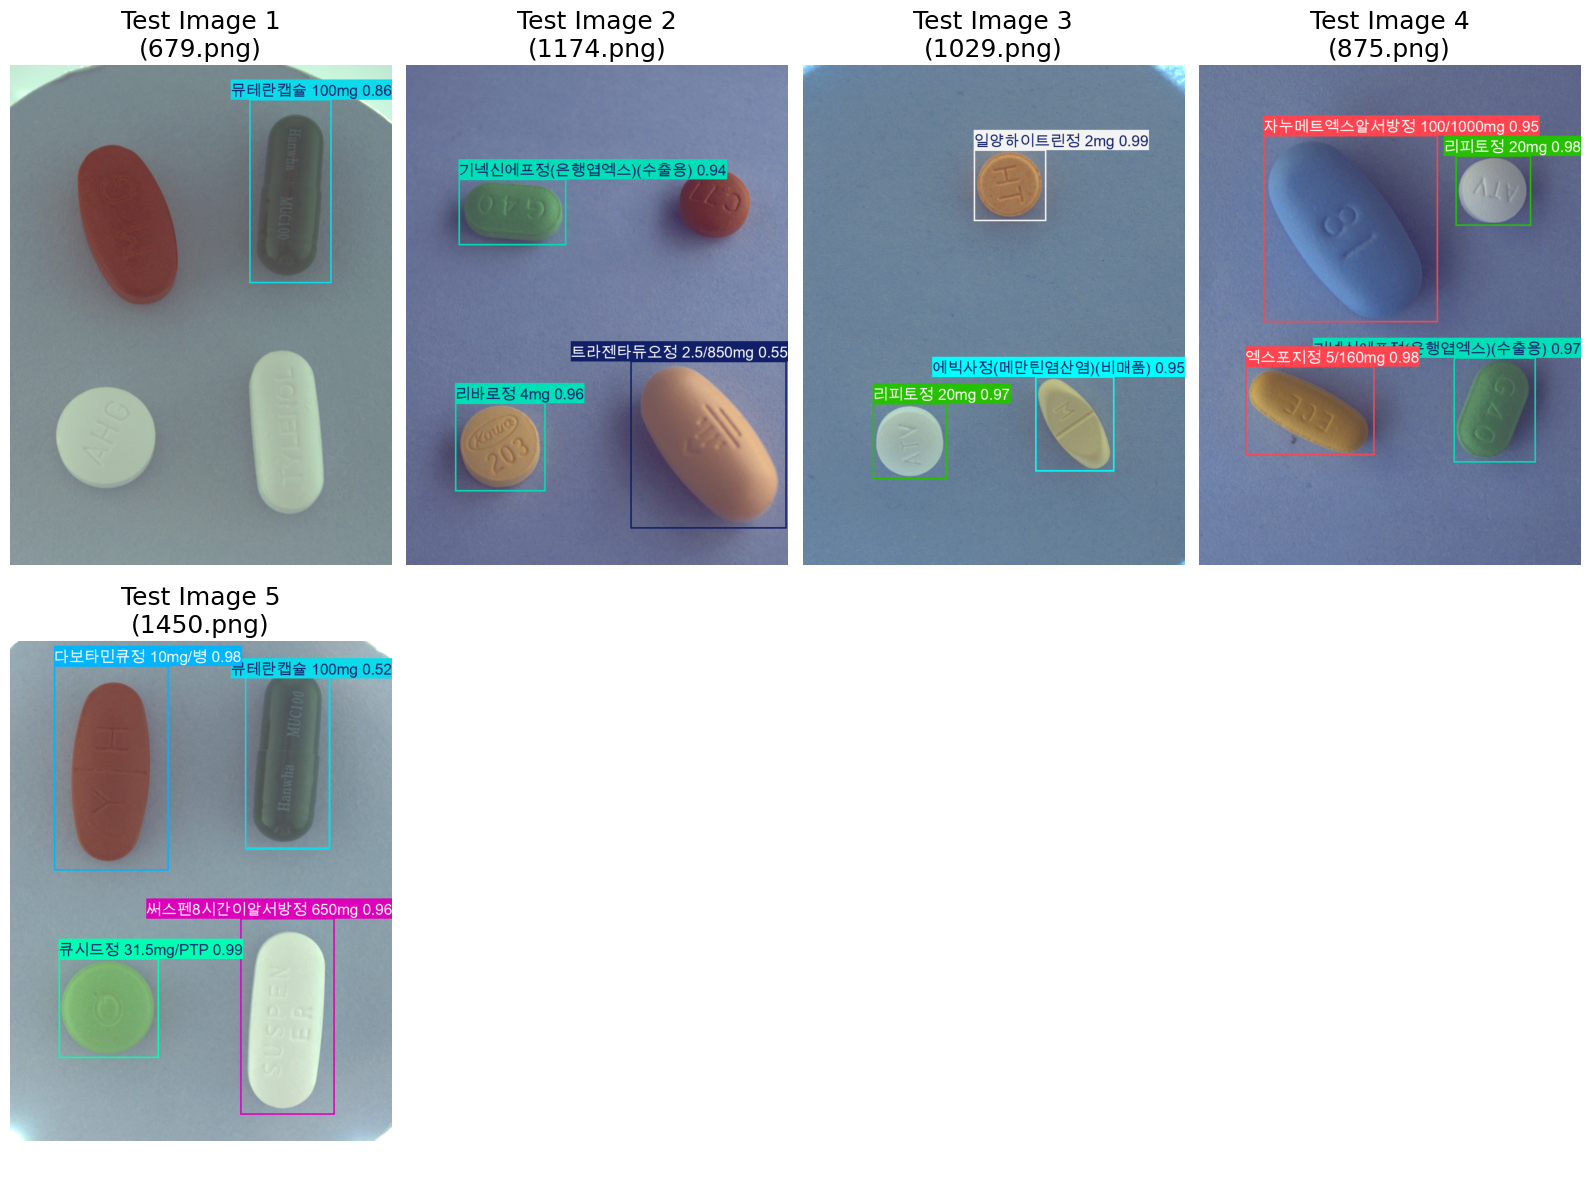

In [ ]:
import cv2
import math
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

MODEL_PATH = "/content/runs/detect/pill-detection/yolo26m_train/weights/best.pt"
model = YOLO(MODEL_PATH)

TEST_IMG_DIR = "/content/test_images"



### 전체 이미지 중 5장 랜덤으로 출력할 때 ###
NUM_SAMPLES = 5
all_test_imgs = glob(os.path.join(TEST_IMG_DIR, "*.png"))

random.seed(42)
sample_img_paths = random.sample(all_test_imgs, min(len(all_test_imgs), NUM_SAMPLES))
# =========================================================
### 특정 파일 지정 출력할 때 ###
# target_files = ['198.png', '189.png', '100.png']
# sample_img_paths = [os.path.join(TEST_IMG_DIR, f) for f in target_files]
# =========================================================


COLS = 4
rows = math.ceil(len(sample_img_paths) / COLS)

plt.figure(figsize=(16, 6 * rows))

for i, img_path in enumerate(sample_img_paths):
    results = model.predict(source=img_path, conf=0.25, imgsz=768, verbose=False)

    res_plotted = results[0].plot(
            font="NanumGothic.ttf",
            labels=True,
            conf=True,
            line_width=4,
            font_size=None
    )

    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, COLS, i + 1)
    plt.imshow(res_rgb)

    img_name = Path(img_path).name
    plt.title(f"Test Image {i+1}\n({img_name})", fontsize=18)
    plt.axis('off')

for j in range(len(sample_img_paths), rows * COLS):
    plt.subplot(rows, COLS, j + 1)
    plt.axis('off')

plt.tight_layout()
plt.show()